# Рекомендации против оттока: Яндекс Лавка

**Бизнес-цель — снизить отток.** Пользователь уходит, когда заказывать неудобно или неинтересно. Рекомендации помогают с обеих сторон:
- **быстро собрать привычную корзину** («Купить снова») — меньше усилий на каждый заказ;
- **дать повод вернуться** — дополняющие товары и то, что нравится похожим людям.

Как это связано с оттоком в этой работе:
1. **Что показать** — строим рекомендации и меряем, насколько они угадывают следующий заказ (части I).
2. **Кому показать** — находим пользователей в зоне риска оттока и проверяем, что им есть что предложить (раздел 6).
3. **Как доказать эффект** — в логах нет связи покупки с рекомендацией и нет контрольной группы, поэтому влияние на отток проверяется только A/B-тестом (часть III).

**Данные:** [YSDA RecSys 2025 — Lavka](https://www.kaggle.com/datasets/thekabeton/ysda-recsys-2025-lavka-dataset): показы, клики, корзины и покупки за ~13 месяцев.

In [1]:
import datetime as dt
import pathlib

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.sparse as sp
from scipy.stats import norm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)
plt.rcParams["figure.figsize"] = (12, 4)

DAY = 24 * 60 * 60  # timestamp в данных — секунды Unix
SEED = 42
DATA = pathlib.Path(kagglehub.dataset_download("thekabeton/ysda-recsys-2025-lavka-dataset"))

## 1. Данные

Берём покупки. Товары, которые попадают в заказ автоматически (пакет, сэмплы, промо-подарки), исключаем: иначе модель будет рекомендовать пакет.
Правило: ≥10 покупок и ни одного добавления в корзину, плюс служебные категории.

In [2]:
raw = pl.scan_parquet(DATA / "train.parquet")
catalog = raw.group_by("product_id").agg(pl.col("product_name").first(), pl.col("product_category").first()).collect()
events = raw.select("user_id", "product_id", "action_type", "source_type", "timestamp").collect()

item_actions = events.group_by("product_id").agg(
    (pl.col("action_type") == "AT_Purchase").sum().alias("purchases"),
    (pl.col("action_type") == "AT_CartUpdate").sum().alias("cart_updates"),
)
SERVICE_CATEGORIES = ["Расходные материалы (комплектация заказов)", "Сэмплы", "Маркетинг", "Обеды для курьеров"]
service_items = pl.concat([
    item_actions.filter((pl.col("purchases") >= 10) & (pl.col("cart_updates") == 0)).select("product_id"),
    catalog.filter(pl.col("product_category").is_in(SERVICE_CATEGORIES)).select("product_id"),
]).unique()

# заказ = покупки одного пользователя с одним timestamp
purchases = (
    events.filter(pl.col("action_type") == "AT_Purchase")
    .join(service_items, on="product_id", how="anti")
    .select("user_id", "product_id", "timestamp")
    .unique()
    .sort("timestamp", "user_id", "product_id")  # фиксируем порядок для воспроизводимости
)
orders = purchases.group_by("user_id", "timestamp").len("basket_size").sort("timestamp", "user_id")
purchases = purchases.join(orders.with_row_index("order_id").select("user_id", "timestamp", "order_id"),
                           on=["user_id", "timestamp"]).sort("timestamp", "user_id", "product_id")

print(f"служебных товаров исключено: {service_items.height}")
print(f"покупателей: {orders['user_id'].n_unique()}, заказов: {orders.height}, позиций: {purchases.height}, "
      f"медиана корзины: {orders['basket_size'].median():.0f}")

служебных товаров исключено: 46
покупателей: 1848, заказов: 35696, позиций: 202121, медиана корзины: 4


### Насколько велик отток
Пользователь, заказывавший в последние 60 дней до даты X, **ушёл**, если не сделал ни одного заказа за 30 дней после X.

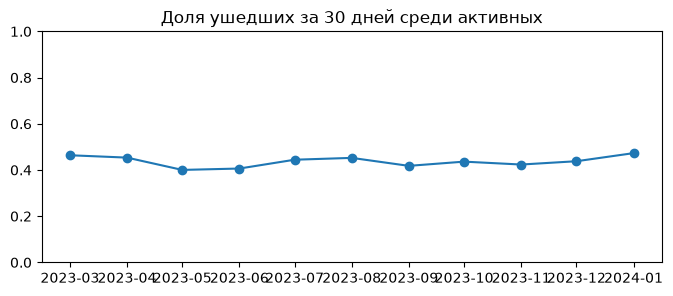

date,active_users,churn_rate
"datetime[μs, UTC]",i64,f64
2023-03-01 00:00:00 UTC,649,0.464
2023-04-01 00:00:00 UTC,657,0.454
2023-05-01 00:00:00 UTC,637,0.4
2023-06-01 00:00:00 UTC,635,0.406
2023-07-01 00:00:00 UTC,675,0.444
2023-08-01 00:00:00 UTC,683,0.452
2023-09-01 00:00:00 UTC,682,0.418
2023-10-01 00:00:00 UTC,736,0.436
2023-11-01 00:00:00 UTC,779,0.424


In [3]:
ACTIVE_DAYS, CHURN_DAYS = 60, 30


def churn_at(x):
    t = int(x.timestamp())
    active = orders.filter(pl.col("timestamp").is_between(t - ACTIVE_DAYS * DAY, t, closed="left"))["user_id"].unique()
    back = orders.filter(pl.col("timestamp").is_between(t, t + CHURN_DAYS * DAY, closed="left"))["user_id"].unique()
    return {"date": x, "active_users": len(active), "churn_rate": 1 - len(set(active) & set(back)) / len(active)}


churn = pl.DataFrame([churn_at(x) for x in pl.datetime_range(
    dt.datetime(2023, 3, 1), dt.datetime(2024, 1, 1), "1mo", eager=True, time_zone="UTC")])
plt.figure(figsize=(8, 3))
plt.plot(churn["date"], churn["churn_rate"], marker="o")
plt.title("Доля ушедших за 30 дней среди активных"); plt.ylim(0, 1); plt.show()
churn.with_columns(pl.col("churn_rate").round(3))

In [4]:
first_buy = purchases.group_by("user_id", "product_id").agg(pl.col("timestamp").min().alias("first_ts"))
repeat_share = purchases.join(first_buy, on=["user_id", "product_id"]).select(
    (pl.col("timestamp") > pl.col("first_ts")).mean()).item()
print(f"доля позиций, которые пользователь уже покупал раньше: {repeat_share:.1%}")

доля позиций, которые пользователь уже покупал раньше: 49.1%


Отток высокий, а корзина наполовину состоит из повторов. Значит, главный рычаг удержания — сделать повторный заказ максимально быстрым,
а второй — аккуратно расширять корзину новыми, но релевантными товарами.

## 2. Как оцениваем рекомендации

- **Разрез по времени:** всё до даты `cut` — история, цель — товары **первого заказа** пользователя в следующие 30 дней.
- `2023-12-04` — валидация (подбор параметров), `2024-01-03` — тест.
- Оцениваем пользователей с историей покупок; новых обслуживает «Популярное».
- **Метрики:** Recall@10 (доля товаров следующего заказа в top-10), HitRate@10 (угадали хотя бы один товар), Coverage (доля каталога, которая вообще попадает в рекомендации).

In [5]:
HORIZON_DAYS = 30
K = 10
EPS = 1e-6  # малый вклад популярности: разбивает ничьи между товарами с одинаковым скором


class Split:
    def __init__(self, cut):
        self.name = str(cut.date())
        self.cut = int(cut.timestamp())
        self.hist = purchases.filter(pl.col("timestamp") < self.cut)
        self.items = np.sort(self.hist["product_id"].unique().to_numpy())
        self.users = np.sort(self.hist["user_id"].unique().to_numpy())
        self.user_index = pl.DataFrame({"user_id": self.users, "u": np.arange(len(self.users))})
        self.item_index = pl.DataFrame({"product_id": self.items, "i": np.arange(len(self.items))})
        self.hist = self.hist.join(self.user_index, on="user_id").join(self.item_index, on="product_id")
        self.shape = (len(self.users), len(self.items))

        future = purchases.filter(pl.col("timestamp").is_between(self.cut, self.cut + HORIZON_DAYS * DAY, closed="left"))
        first = future.filter(pl.col("timestamp") == pl.col("timestamp").min().over("user_id"))
        target = first.group_by("user_id").agg(pl.col("product_id")).sort("user_id")
        warm = target.join(self.user_index, on="user_id", how="semi")
        self.n_cold = target.height - warm.height
        self.target_users = warm["user_id"].to_numpy()
        self.t_rows = np.searchsorted(self.users, self.target_users)
        self.gt = [set(x) for x in warm["product_id"].to_list()]

    def matrix(self, tau=None):
        """Пользователь × товар: число заказов с товаром, или с затуханием exp(-давность/tau дней)."""
        w = pl.lit(1.0) if tau is None else (-(self.cut - pl.col("timestamp")) / (tau * DAY)).exp()
        h = self.hist.with_columns(w.alias("w"))
        return sp.csr_matrix((h["w"].to_numpy(), (h["u"].to_numpy(), h["i"].to_numpy())), shape=self.shape)

    def popularity(self, days=30):
        """Число покупателей товара за последние дни, нормировано на максимум."""
        c = self.hist.filter(pl.col("timestamp") >= self.cut - days * DAY).group_by("i").agg(pl.col("u").n_unique())
        v = np.zeros(len(self.items))
        v[c["i"].to_numpy()] = c["u"].to_numpy()
        return v / v.max()


def top_k(scores, k=K):
    idx = np.argpartition(-scores, k, axis=1)[:, :k]
    return np.take_along_axis(idx, np.argsort(-np.take_along_axis(scores, idx, 1), axis=1), 1)


def evaluate(scores, s, k=K):
    top = top_k(scores, k)
    hits = [len(set(s.items[row].tolist()) & gt) for row, gt in zip(top, s.gt)]
    return {f"Recall@{k}": np.mean([h / len(gt) for h, gt in zip(hits, s.gt)]),
            f"HitRate@{k}": np.mean([h > 0 for h in hits]),
            "Coverage": len(np.unique(top)) / len(s.items)}


val = Split(dt.datetime(2023, 12, 4, tzinfo=dt.timezone.utc))
test = Split(dt.datetime(2024, 1, 3, tzinfo=dt.timezone.utc))
for s in (val, test):
    print(f"{s.name}: пользователей с историей в цели {len(s.t_rows)}, новых {s.n_cold}, товаров {len(s.items)}")

2023-12-04: пользователей с историей в цели 552, новых 137, товаров 11064
2024-01-03: пользователей с историей в цели 552, новых 112, товаров 11593


## 3. Эвристики

| Поверхность | Правило |
|---|---|
| **«Популярное»** (главная, новые пользователи) | товары с наибольшим числом покупателей за 30 дней |
| **«Купить снова»** | как часто пользователь покупал товар, с затуханием по давности: $\sum_{\text{заказы}} e^{-\Delta t/\tau}$ |
| **«Недавно интересовались»** | товары, которые пользователь кликал или добавлял в корзину за 14 дней (часто — брошенная корзина) |

Период затухания $\tau$ подбираем на валидации.

In [6]:
def rec_popular(s):
    return np.tile(s.popularity(), (len(s.t_rows), 1))


def rec_buy_again(s, tau=30):
    return s.matrix(tau)[s.t_rows].toarray() + EPS * s.popularity()


def rec_recent_interest(s, days=14, tau=3):
    e = (events.filter(pl.col("action_type").is_in(["AT_Click", "AT_CartUpdate"])
                       & pl.col("timestamp").is_between(s.cut - days * DAY, s.cut, closed="left"))
         .join(s.user_index, on="user_id").join(s.item_index, on="product_id"))
    w = np.exp(-(s.cut - e["timestamp"].to_numpy()) / (tau * DAY))
    M = sp.csr_matrix((w, (e["u"].to_numpy(), e["i"].to_numpy())), shape=s.shape)
    return M[s.t_rows].toarray() + EPS * s.popularity()


pl.DataFrame([{"tau": str(t), **evaluate(rec_buy_again(val, t), val)} for t in (7, 14, 30, 60, None)])

tau,Recall@10,HitRate@10,Coverage
str,f64,f64,f64
"""7""",0.175486,0.538043,0.233189
"""14""",0.18534,0.552536,0.244667
"""30""",0.194422,0.574275,0.254338
"""60""",0.195578,0.59058,0.253796
"""None""",0.162374,0.528986,0.223247


In [7]:
TAU = 30  # 30 и 60 дней почти равны, «просто частота» (None) заметно хуже: недавние покупки важнее старых

## 4. Классические подходы

**Item-based CF — «С этим товаром покупают».** Товары похожи, если их часто кладут в одну корзину:
$\text{sim}(i,j) = \frac{c_{ij}}{\sqrt{n_i n_j} + 5}$, где $c_{ij}$ — число заказов с обоими товарами (5 гасит шум у редких товаров).
Скор товара для пользователя — сумма похожестей на то, что он покупал.

**User-based CF — «Покупают похожие на вас».** Пользователь — вектор купленных товаров (редкие товары весят больше, IDF).
Берём 50 самых похожих пользователей и рекомендуем то, что покупали они.

**Content-based — «Похожие товары».** TF-IDF по буквосочетаниям названия и категории (устойчиво к падежам: «молоко» ≈ «молока»).
Профиль пользователя — сумма векторов купленных товаров.

In [8]:
def item_similarity(s, shrink=5.0):
    h = s.hist
    B = sp.csr_matrix((np.ones(h.height), (h["order_id"].rank("dense").to_numpy() - 1, h["i"].to_numpy())))
    C = (B.T @ B).tocoo()
    n = np.asarray(B.sum(0)).ravel()
    off_diag = C.row != C.col
    r, c = C.row[off_diag], C.col[off_diag]
    return sp.csr_matrix((C.data[off_diag] / (np.sqrt(n[r] * n[c]) + shrink), (r, c)), shape=(len(s.items),) * 2)


def rec_item_cf(s):
    return (s.matrix(TAU)[s.t_rows] @ item_similarity(s)).toarray() + EPS * s.popularity()


def rec_user_cf(s, n_neighbors=50):
    X = (s.matrix() > 0).astype(float)
    idf = np.log(X.shape[0] / (1 + np.asarray(X.sum(0)).ravel()))
    Xw = normalize(X @ sp.diags(idf))
    sims = (Xw[s.t_rows] @ Xw.T).toarray()
    sims[np.arange(len(s.t_rows)), s.t_rows] = 0  # сам себе не сосед
    kth = -np.partition(-sims, n_neighbors, axis=1)[:, [n_neighbors - 1]]
    sims[sims < kth] = 0
    return (sp.csr_matrix(sims) @ X).toarray() + EPS * s.popularity()


def item_text_vectors(s):
    names = pl.DataFrame({"product_id": s.items}).join(catalog, on="product_id", how="left")
    texts = (names["product_category"].fill_null("") + " " + names["product_name"].fill_null("")).str.to_lowercase()
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True).fit_transform(texts)


def rec_content(s):
    X = item_text_vectors(s)
    profile = normalize(s.matrix(TAU)[s.t_rows] @ X)
    return (profile @ X.T).toarray() + EPS * s.popularity()


MODELS = {"popular": rec_popular, "buy_again": rec_buy_again, "recent_interest": rec_recent_interest, "item_cf": rec_item_cf,
          "user_cf": rec_user_cf, "content": rec_content}
scores = {s.name: {m: f(s) for m, f in MODELS.items()} for s in (val, test)}
results = [{"model": m, **evaluate(S, test)} for m, S in scores[test.name].items()]
pl.DataFrame(results).with_columns(pl.selectors.float().round(4))

model,Recall@10,HitRate@10,Coverage
str,f64,f64,f64
"""popular""",0.0285,0.1576,0.0009
"""buy_again""",0.1705,0.5797,0.2414
"""recent_interest""",0.1033,0.404,0.1945
"""item_cf""",0.0992,0.4022,0.2849
"""user_cf""",0.0581,0.2699,0.0696
"""content""",0.0978,0.3822,0.2447


**Как читать:**
- «Купить снова» — безусловный лидер (Recall@10 ≈ 0.17, у 58% пользователей угадан хотя бы один товар): корзина Лавки наполовину из повторов.
- «Недавно интересовались», item-CF и content-based — примерно вдвое слабее, но дают другие товары и бо́льшее покрытие каталога.
- «Популярное» слабое (≈ 0.03) и показывает всем одно и то же (Coverage < 0.1%) — это только запасной вариант для новичков.

## 5. Гибрид: взвешенная смесь

Каждая модель хороша в своём: «Купить снова» — повторы, «Недавно интересовались» — брошенные корзины, CF и content — дополняющие и похожие товары, популярное — подстраховка.
Смешиваем скоры: каждую модель приводим к шкале [0, 1] внутри пользователя и складываем с весами. Веса подбираем перебором на **валидации**, проверяем на тесте.

In [9]:
def scale_rows(S):
    S = S - S.min(1, keepdims=True)
    return S / (S.max(1, keepdims=True) + 1e-12)


def rec_hybrid(s, w):
    sc = scores[s.name]
    return sum(weight * scale_rows(sc[m]) for m, weight in w.items())


BLEND = ["buy_again", "recent_interest", "item_cf", "content", "popular"]
grid = [dict(zip(BLEND, (1.0, a, b, c, d)))
        for a in (0, 0.25, 0.5, 1) for b in (0, 0.1, 0.25) for c in (0, 0.1, 0.25) for d in (0, 0.05)]
search = pl.DataFrame([{**w, **evaluate(rec_hybrid(val, w), val)} for w in grid]).sort("Recall@10", descending=True)
BEST_W = {m: search.row(0, named=True)[m] for m in BLEND}
print("лучшие веса на валидации:", BEST_W)
search.head(5)

лучшие веса на валидации: {'buy_again': 1.0, 'recent_interest': 0.0, 'item_cf': 0.0, 'content': 0.1, 'popular': 0.05}


buy_again,recent_interest,item_cf,content,popular,Recall@10,HitRate@10,Coverage
f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.0,0.0,0.1,0.05,0.198335,0.568841,0.269523
1.0,0.25,0.0,0.0,0.0,0.195487,0.577899,0.255604
1.0,0.25,0.25,0.25,0.0,0.194933,0.57971,0.281453
1.0,0.0,0.0,0.0,0.0,0.194422,0.574275,0.254338
1.0,0.25,0.0,0.1,0.05,0.194385,0.574275,0.257231


In [10]:
hybrid_scores = rec_hybrid(test, BEST_W)
results.append({"model": "hybrid", **evaluate(hybrid_scores, test)})
final = pl.DataFrame(results).sort("Recall@10", descending=True).with_columns(pl.selectors.float().round(4))
final

model,Recall@10,HitRate@10,Coverage
str,f64,f64,f64
"""hybrid""",0.1713,0.5707,0.2571
"""buy_again""",0.1705,0.5797,0.2414
"""recent_interest""",0.1033,0.404,0.1945
"""item_cf""",0.0992,0.4022,0.2849
"""content""",0.0978,0.3822,0.2447
"""user_cf""",0.0581,0.2699,0.0696
"""popular""",0.0285,0.1576,0.0009


In [11]:
def per_user_recall(S, s):
    return np.array([len(set(s.items[row].tolist()) & gt) / len(gt) for row, gt in zip(top_k(S), s.gt)])


rng = np.random.default_rng(SEED)
d = per_user_recall(hybrid_scores, test) - per_user_recall(scores[test.name]["buy_again"], test)
boot = d[rng.integers(0, len(d), (5000, len(d)))].mean(1)
print(f"гибрид − «Купить снова»: Recall@10 {d.mean():+.4f}, 95% ДИ [{np.percentile(boot, 2.5):+.4f}, {np.percentile(boot, 97.5):+.4f}]")

гибрид − «Купить снова»: Recall@10 +0.0008, 95% ДИ [-0.0065, +0.0093]


**Результат гибрида.** На валидации лучшая смесь — «Купить снова» + немного content-based и популярного. На тесте она даёт +0.001 Recall@10, и 95%-интервал включает ноль: **прирост — в пределах шума**.
Более сложные варианты (смесь рангов, квоты «k слотов под новое») на этих данных тоже не обгоняют «Купить снова»: в едином top-10 привычные товары почти всегда вероятнее любого нового.

**Вывод для бизнеса:** основа персонализации против оттока — хорошо сделанный «Купить снова» (свежая история, затухание по давности). Гибрид оставляем как расширение
для блоков «С этим товаром покупают» и «Похожие товары», где повторы не нужны, а его выгоду проверяем онлайн.

### Как это выглядит в продукте

In [12]:
product_names = dict(zip(catalog["product_id"].to_list(), catalog["product_name"].to_list()))


def show(item_idx, s):
    return pl.DataFrame({"товар": [product_names[p] for p in s.items[item_idx].tolist()]})


anchor = int(np.argmax(test.popularity()))  # самый популярный товар месяца
print("Товар:", product_names[test.items[anchor]])
sim = item_similarity(test)[anchor].toarray().ravel()
print("С этим товаром покупают:"); display(show(np.argsort(-sim)[:5], test))
X_text = item_text_vectors(test)
sim = (X_text @ X_text[anchor].T).toarray().ravel(); sim[anchor] = -1
print("Похожие товары (замены):"); display(show(np.argsort(-sim)[:5], test))

Товар: Мандарины мини, 500 г
С этим товаром покупают:


товар
str
"""Гранат зёрна «Из Лавки», 100 г"""
"""Йогурт питьевой Epica с клубникой и маракуйей 2,5%, 260 г"""
"""Апельсины сладкие, 500 г"""
"""Кофе в дрип-пакетах «Из Лавки» микс Южная Америка, 6 шт."""
"""Сочни с творогом Хлебная страна «Бкк», 120 г"""


Похожие товары (замены):


товар
str
"""Мандарины ЮАР, 500 г"""
"""Мандарины Муркотт, 500 г"""
"""Мандарины, 1 кг"""
"""Мандарины, 1 кг"""
"""Мандарины беби, 500 г"""


In [13]:
row = int(np.argsort([len(g) for g in test.gt])[len(test.gt) // 2])  # пользователь со «средней» корзиной
bought = set(test.hist.filter(pl.col("u") == test.t_rows[row])["product_id"].to_list())
rec = top_k(hybrid_scores[[row]])[0]
show(rec, test).with_columns(
    pl.Series("покупал раньше", [p in bought for p in test.items[rec].tolist()]),
    pl.Series("в следующем заказе", [p in test.gt[row] for p in test.items[rec].tolist()]),
)

товар,покупал раньше,в следующем заказе
str,bool,bool
"""Омлет с лососем и песто «Есть Горячее», 240 г""",true,false
"""Омлет с беконом и творожным сыром «Есть Горячее», 220 г""",true,false
"""Завтрак Деревенский с беконом «Есть Горячее», 230 г""",true,false
"""Гранд Латте, 400 мл""",true,true
"""Сэндвич-ролл с горбушей и яйцом «Нияма», 155 г""",true,false
"""Драники с форелью и сметаной «Есть Горячее», 200 г""",true,true
"""Творог 5% «Из Лавки» клубника-земляника со сливками, 140 г""",true,false
"""Мороженое пломбир «Золотой стандарт» с таёжной черникой в ва…",true,false
"""Блины с сёмгой «Шоколадница», 150 г""",true,false


## 6. Против оттока: кому и что показать

Рекомендации сами по себе не удерживают — удерживает **действие**: пуш «пора заказать снова» с персональной корзиной, промокод, напоминание.
Такие действия стоят денег и раздражают, если слать всем. Поэтому нужны две вещи:
1. **Скоринг риска:** кто из активных пользователей, скорее всего, уйдёт в ближайшие 30 дней.
2. **Проверка:** есть ли что предложить этим людям — угадывают ли рекомендации их следующий заказ.

Признаки риска — простые и объяснимые: сколько дней с последнего заказа, сколько заказов за 60 и 180 дней, «просрочка» (дни с последнего заказа / обычный интервал между заказами).
Модель — логистическая регрессия: обучаем на разрезе валидации, проверяем на тесте.

In [14]:
def risk_frame(s):
    """Активные пользователи на дату cut, признаки риска и факт ухода (нет заказа за 30 дней)."""
    o = orders.filter(pl.col("timestamp") < s.cut)
    feats = o.group_by("user_id").agg(
        ((s.cut - pl.col("timestamp").max()) / DAY).alias("days_since_last"),
        (pl.col("timestamp") >= s.cut - 60 * DAY).sum().alias("orders_60d"),
        (pl.col("timestamp") >= s.cut - 180 * DAY).sum().alias("orders_180d"),
        ((pl.col("timestamp").max() - pl.col("timestamp").min()) / DAY / (pl.len() - 1).clip(lower_bound=1)).alias("avg_gap"),
    ).filter(pl.col("orders_60d") > 0)
    feats = feats.with_columns((pl.col("days_since_last") / pl.col("avg_gap").clip(lower_bound=1)).alias("overdue"))
    back = (orders.filter(pl.col("timestamp").is_between(s.cut, s.cut + CHURN_DAYS * DAY, closed="left"))
            .select("user_id").unique().with_columns(pl.lit(0).alias("churned")))
    return feats.join(back, on="user_id", how="left").with_columns(pl.col("churned").fill_null(1)).sort("user_id")


RISK_FEATURES = ["days_since_last", "orders_60d", "orders_180d", "overdue"]
risk_train, risk_test = risk_frame(val), risk_frame(test)
risk_model = make_pipeline(StandardScaler(), LogisticRegression())
risk_model.fit(np.log1p(risk_train.select(RISK_FEATURES).to_numpy()), risk_train["churned"].to_numpy())
risk_test = risk_test.with_columns(
    pl.Series("risk", risk_model.predict_proba(np.log1p(risk_test.select(RISK_FEATURES).to_numpy()))[:, 1]))

y = risk_test["churned"].to_numpy()
print(f"активных на {test.name}: {risk_test.height}, ушли за 30 дней: {y.mean():.1%}")
pl.DataFrame([{"скоринг": name, "ROC-AUC": round(roc_auc_score(y, v), 3)} for name, v in {
    "логрег по 4 признакам": risk_test["risk"].to_numpy(),
    "только «давно не заказывал»": risk_test["days_since_last"].to_numpy(),
    "только «мало заказов»": -risk_test["orders_60d"].to_numpy(),
}.items()])

активных на 2024-01-03: 926, ушли за 30 дней: 47.4%


скоринг,ROC-AUC
str,f64
"""логрег по 4 признакам""",0.829
"""только «давно не заказывал»""",0.738
"""только «мало заказов»""",0.804


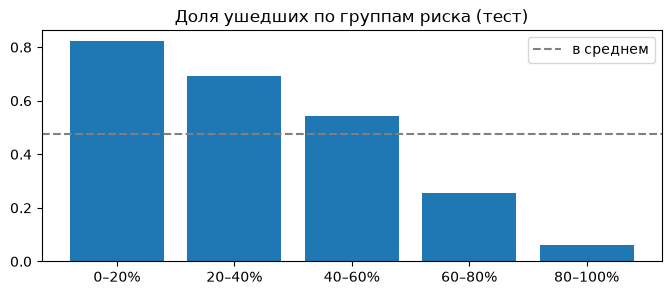

группа риска (top-%),users,churn_rate
str,u32,f64
"""0–20%""",185,0.822
"""20–40%""",185,0.692
"""40–60%""",186,0.543
"""60–80%""",185,0.254
"""80–100%""",185,0.059


In [15]:
risk_test = risk_test.with_columns((pl.col("risk").rank("ordinal", descending=True) * 5 // (pl.len() + 1)).alias("q"))
by_group = risk_test.group_by("q").agg(pl.len().alias("users"), pl.col("churned").mean().alias("churn_rate")).sort("q")
by_group = by_group.with_columns(pl.format("{}–{}%", pl.col("q") * 20, pl.col("q") * 20 + 20).alias("группа риска (top-%)"))
plt.figure(figsize=(8, 3))
plt.bar(by_group["группа риска (top-%)"], by_group["churn_rate"])
plt.axhline(y.mean(), color="gray", ls="--", label="в среднем"); plt.legend()
plt.title("Доля ушедших по группам риска (тест)"); plt.show()
by_group.select("группа риска (top-%)", "users", pl.col("churn_rate").round(3))

**Результат:** простая логистическая регрессия на 4 признаках отделяет уходящих хорошо (ROC-AUC ≈ 0.83). В 20% самых рискованных уходят **82%**, в 20% самых надёжных — **6%**.
Главный сигнал — частота заказов, а не только давность. Значит, удерживающие действия можно направлять точечно, а не слать всем.

**Что показать группе риска.** Из тех, кто всё-таки сделал заказ, сравним качество рекомендаций для группы высокого риска (top-40%) и остальных.
Если рекомендации угадывают заказ и у рискованных, пуш «Ваша корзина готова» со скидкой — осмысленное удерживающее действие.

In [16]:
high_risk = set(risk_test.filter(pl.col("q") <= 1)["user_id"].to_list())
is_high = np.array([u in high_risk for u in test.target_users.tolist()])
rows = []
for name, S in {"hybrid": hybrid_scores, "buy_again": scores[test.name]["buy_again"], "popular": scores[test.name]["popular"]}.items():
    r = per_user_recall(S, test)
    rows.append({"model": name, "Recall@10 высокий риск": r[is_high].mean(), "Recall@10 остальные": r[~is_high].mean()})
print(f"вернувшихся пользователей из группы высокого риска: {is_high.sum()}, остальных: {(~is_high).sum()}")
pl.DataFrame(rows).with_columns(pl.selectors.float().round(4))

вернувшихся пользователей из группы высокого риска: 90, остальных: 462


model,Recall@10 высокий риск,Recall@10 остальные
str,f64,f64
"""hybrid""",0.1211,0.181
"""buy_again""",0.1258,0.1792
"""popular""",0.0195,0.0303


Для группы риска рекомендации угадывают следующий заказ хуже (Recall@10 ≈ 0.12 против 0.18): история у таких пользователей короче и реже обновляется.
Но это всё равно примерно в 6 раз лучше популярного — персональная корзина в пуше осмысленна.

**Сценарий удерживающей кампании:**
1. Ежедневно считаем риск для активных пользователей.
2. Группе высокого риска отправляем пуш: персональная корзина из гибрида («Купить снова» + то, что обычно покупают вместе) + промокод на следующий заказ.
3. **Обязательно** оставляем случайную контрольную группу без пуша — только так видно, снизился ли отток (часть III).

## Итоги части I

| Что требует ТЗ | Что сделано | Результат на тесте (Recall@10) |
|---|---|---|
| Эвристики | «Популярное», «Купить снова», «Недавно интересовались» | 0.03 / **0.17** / 0.10 |
| Content-based | TF-IDF по названию и категории → «Похожие товары» | 0.10 |
| Коллаборативные | item-based («С этим товаром покупают»), user-based | 0.10 / 0.06 |
| Гибрид | взвешенная смесь, веса подобраны на валидации | 0.17, прирост в пределах шума |
| Связь с оттоком | скоринг риска + персональная корзина для группы риска | ROC-AUC 0.83, в top-20% риска уходят 82% |

**Главное:** для удержания работают простые вещи — «Купить снова» (что показать) и скоринг по частоте заказов (кому показать). Сложные модели добавляют проценты, которые на таких данных не отличить от шума.

---
# Часть II. Проблемы и ограничения

Схема: **проблема → как решить → минус решения → что делать**.

## II.a. Проблемы подходов

### 1. Холодный старт пользователя
**Проблема.** У нового пользователя нет истории — CF и «Купить снова» бесполезны. А именно новички уходят чаще всего.

In [17]:
new_share = test.n_cold / (test.n_cold + len(test.t_rows))
print(f"доля пользователей без истории среди заказавших в тестовом окне: {new_share:.0%}")

доля пользователей без истории среди заказавших в тестовом окне: 17%


**Как решить.** «Популярное» в городе, контекст текущей сессии (поиск, клики, корзина), короткий онбординг «что вы обычно покупаете».

**Минус решения.** Онбординг — лишний шаг до первого заказа, часть новичков уйдёт на нём. Популярное одинаково для всех.

**Что делать.** Онбординг необязательный и после первого заказа; до него — сессионные рекомендации. Уже после одного заказа «Купить снова» работает лучше популярного.

### 2. Холодный старт товара
**Проблема.** Новый товар никто не покупал → CF его не рекомендует.

**Как решить.** Content-based (название, категория, картинка) даёт похожие товары сразу; небольшая квота показов для новинок.

**Минус решения.** Похожий текст ≠ похожий вкус и цена. Показы новинок стоят кликов.

**Что делать.** Content-вектор как старт, по мере накопления покупок — переход на CF.

### 3. Пузырь повторов и популярность
**Проблема.** Модель, оптимизированная по Recall, предлагает почти только уже купленное. Корзина не расширяется, сервис «приедается».

In [18]:
def already_bought_share(S, s):
    M = s.matrix()[s.t_rows]
    top = top_k(S)
    return np.mean([M[r, top[r]].toarray().ravel() > 0 for r in range(len(top))])


hist_sets = [set(test.hist.filter(pl.col("u") == u)["product_id"].to_list()) for u in test.t_rows]
actual = np.mean([p in h for gt, h in zip(test.gt, hist_sets) for p in gt])
pl.DataFrame([{"что": "реальный следующий заказ", "доля уже купленного": actual}] +
             [{"что": m, "доля уже купленного": already_bought_share(S, test)}
              for m, S in {"hybrid": hybrid_scores, "item_cf": scores[test.name]["item_cf"],
                           "user_cf": scores[test.name]["user_cf"]}.items()]).with_columns(pl.selectors.float().round(3))

что,доля уже купленного
str,f64
"""реальный следующий заказ""",0.391
"""hybrid""",0.926
"""item_cf""",0.657
"""user_cf""",0.503


В реальных заказах уже купленное — 39%, а в top-10 гибрида — 93%: модель, оптимизированная по Recall, почти не предлагает нового.

**Как решить.** Отдельные блоки «Купить снова» и «Может понравиться» (без купленного), квота «2 из 10 — новое», реранжирование на разнообразие.

**Минус решения.** Краткосрочные метрики (Recall, CTR) падают: новое покупают реже привычного.

**Что делать.** Решать по A/B с долгосрочными метриками — удержание, число категорий в корзине, а не по оффлайн-Recall.

### 4. Петля обратной связи
**Проблема.** Логи собраны под действием текущей рекомендательной системы: люди покупают то, что им показали. Новая модель учится повторять старую.

In [19]:
carts = events.filter(pl.col("action_type") == "AT_CartUpdate")
REC_SURFACES = ["ST_Upsale", "ST_Feed", "ST_ItemPageCarousel", "ST_SearchComplementRec", "ST_SearchStartRec",
                "ST_CheckoutUpsale", "ST_Uplift", "ST_PreviousBuyHub", "ST_PreviousBuyCarousel"]
print(f"добавлений в корзину с рекомендательных блоков: {carts['source_type'].is_in(REC_SURFACES).mean():.0%}")

добавлений в корзину с рекомендательных блоков: 27%


**Как решить.** Учитывать позицию и блок показа при обучении, взвешивать примеры обратно вероятности показа (IPS), 1–5% трафика — случайная выдача.

**Минус решения.** IPS-веса нестабильны (нужно обрезать), случайная выдача ухудшает опыт части пользователей.

**Что делать.** Честное сравнение моделей — только онлайн (A/B или interleaving).

### 5. Этика и чувствительные товары
**Проблема.** Энергетики и безалкогольное пиво (18+ во многих сетях), детские товары (по ним можно догадаться о беременности — известный кейс Target).
Сколько стоит убрать их из персональной выдачи?

In [20]:
item_cat = pl.DataFrame({"product_id": test.items}).join(catalog, on="product_id", how="left")["product_category"].fill_null("")
SENSITIVE = {"18+ (энергетики, безалкогольное)": r"(?i)энергетик|безалкогольн", "детские товары": r"(?i)детск|подгузник"}
base = evaluate(hybrid_scores, test)["Recall@10"]
rows = []
for name, pattern in SENSITIVE.items():
    mask = item_cat.str.contains(pattern).to_numpy()
    rows.append({"категория": name, "у пользователей в top-10": mask[top_k(hybrid_scores)].any(1).mean(),
                 "Recall@10 без фильтра": base,
                 "Recall@10 с фильтром": evaluate(np.where(mask, -np.inf, hybrid_scores), test)["Recall@10"]})
pl.DataFrame(rows).with_columns(pl.selectors.float().round(3))

категория,у пользователей в top-10,Recall@10 без фильтра,Recall@10 с фильтром
str,f64,f64,f64
"""18+ (энергетики, безалкогольное)""",0.185,0.171,0.161
"""детские товары""",0.114,0.171,0.169


**Как решить.** Слой правил после модели: 18+ — только при подтверждённом возрасте; детское — только в «Купить снова» и никогда в пушах и сегментах; стоп-лист связок для «С этим товаром покупают».

**Минус решения.** Фильтр отрезает то, что части людей действительно нужно: убрать 18+ стоит ~6% Recall@10 (0.171 → 0.161), детское — почти бесплатно (такие товары и так находят в «Купить снова»). Стоп-листы ведутся вручную и неполны.

**Что делать.** Правила задаёт продукт и юристы, а не модель; регулярный аудит выдачи; цена фильтра известна и принимается осознанно.

### 6. Уязвимость к манипуляциям
**Проблема.** «Популярное» и «С этим товаром покупают» считаются по действиям пользователей — их можно накрутить: несколько фейковых аккаунтов с одинаковыми заказами поднимают товар в топ.
Даже без злого умысла один очень активный пользователь искажает связки у редких товаров.

**Как решить.** Считать совместные покупки «один пользователь — один голос», антифрод-фильтр аккаунтов (новые аккаунты с однотипными заказами), минимальное число разных покупателей для связки.

**Минус решения.** Фильтры задевают честных активных покупателей; порог по числу покупателей скрывает редкие, но реальные связки.

**Что делать.** Мониторинг резких скачков популярности товара и ручная проверка перед попаданием в топ.

### 7. Шум в данных
**Проблема.** Самым «популярным товаром» был пакет Лавки — он подкладывается в заказ автоматически (раздел 1).

**Как решить.** Правило «покупается, но не добавляется в корзину» + служебные категории.

**Минус решения.** Правило ошибается на новых промо и может выкинуть реальный товар, купленный через «повторить заказ».

**Что делать.** Флаг «служебный» в каталоге от владельцев ассортимента; правило на данных — страховка и алерт.

## II.b. Проблемы в продакшене

### 1. Время ответа
**Проблема.** Рекомендации на главной нужны за десятки миллисекунд, а считать скоры по всему каталогу для каждого запроса дорого.

**Как решить.** Раз в сутки заранее считать кандидатов (item-CF, user-CF) для каждого пользователя и класть в key-value хранилище; онлайн — только смешать с «Купить снова» и сессией. Таймаут → предпосчитанный список → популярное.

**Минус решения.** Предпосчитанное устаревает за день; два кода признаков (оффлайн и онлайн) расходятся.

**Что делать.** Историю пользователя держать онлайн (дёшево и важнее всего), тяжёлое — в батче; единое описание признаков.

### 2. Устаревание
**Проблема.** Насколько теряется качество, если «Купить снова» посчитано с задержкой?

In [21]:
def stale_buy_again(lag_days):
    s = test
    cut_l = s.cut - lag_days * DAY
    h = s.hist.filter(pl.col("timestamp") < cut_l)
    w = (-(cut_l - h["timestamp"].to_numpy()) / (TAU * DAY))
    M = sp.csr_matrix((np.exp(w), (h["u"].to_numpy(), h["i"].to_numpy())), shape=s.shape)
    return {"задержка, дней": lag_days, "Recall@10": evaluate(M[s.t_rows].toarray() + EPS * s.popularity(), s)["Recall@10"]}


pl.DataFrame([stale_buy_again(d) for d in (0, 7, 14, 30)]).with_columns(pl.col("Recall@10").round(4))

"задержка, дней",Recall@10
i64,f64
0,0.1705
7,0.165
14,0.1515
30,0.131


Неделя задержки стоит ~3% Recall@10, две недели — ~11%, месяц — ~23%: история пользователя «протухает» быстро.

**Как решить.** Историю покупок обновлять сразу после заказа, популярное — ежедневно, CF — ежедневно или еженедельно.

**Минус решения.** Частое переобучение дороже и повышает риск выкатить сломанную модель.

**Что делать.** Автоматические «ворота качества»: новая версия выкатывается, только если на свежих данных не хуже текущей.

### 3. Наличие товара
**Проблема.** Лавка — сеть даркстор с разным ассортиментом. Рекомендация товара, которого нет в магазине, — пустой слот и раздражение.

**Как решить.** Фильтр по остаткам магазина пользователя с добором следующих кандидатов; замена на похожий товар (content-based).

**Минус решения.** Нужны остатки в реальном времени; в маленьком магазине жёсткий фильтр съедает почти всю выдачу.

**Что делать.** Мягкий штраф вместо жёсткого фильтра, магазин — по текущему адресу доставки.

### 4. Сезонность
**Проблема.** Мандарины зимой, мороженое летом, праздники — популярное быстро меняется.

**Как решить.** Короткое окно популярности (7–30 дней), ежедневный пересчёт, промо-календарь.

**Минус решения.** Короткое окно шумное; годовую сезонность по 13 месяцам данных не выучить.

**Что делать.** Сезонность брать из нескольких лет истории или календаря категорий от бизнеса.

### 5. Масштаб и приватность
- **Масштаб.** Здесь ~2.4 тыс. покупателей, в проде — миллионы: CF считается распределённо, похожие товары — через ANN-индекс.
- **Приватность.** История покупок — персональные данные (152-ФЗ): храним агрегаты, удаляем по запросу, никаких выводов вроде «мы заметили, что у вас ребёнок».

---
# Часть III. Оценка в продакшене

## III.1. Дерево метрик

| Уровень | Метрика | Зачем |
|---|---|---|
| **Цель (north star)** | **отток за 30 дней** (или доля пользователей с заказом в следующие 30 дней) | ради этого всё делается |
| Быстрый индикатор | частота заказов на пользователя за 4 недели | реагирует быстрее оттока, сильно с ним связана |
| Заказ | средний чек, число позиций, доля новых для пользователя товаров | растёт ли корзина |
| Блок рекомендаций | CTR, добавления в корзину из блока, время сборки корзины | работает ли конкретный блок |
| ML (оффлайн) | Recall@10, HitRate@10, Coverage | быстрый отбор моделей до A/B |
| **Ограничители** | время ответа p95/p99, доля пустых выдач, отписки от пушей, жалобы, 18+ без проверки возраста | что нельзя ухудшить |

Оффлайн-Recall и отток связаны слабо: +5% Recall не означает −5% оттока. Выгоду показывает только эксперимент.

## III.2. A/B-тест: сколько нужно пользователей
Делим пользователей случайно (не сессии — иначе человек видит обе версии). Оцениваем размер групп на реальных данных:
- **отток** — бинарная метрика, база — текущий уровень оттока;
- **число заказов за 4 недели** — с **CUPED**: вычитаем из метрики её прогноз по периоду до эксперимента, это уменьшает разброс в $1-\rho^2$ раз.

In [22]:
Z = norm.ppf(0.975) + norm.ppf(0.8)  # α = 0.05, мощность 80%
p0 = churn["churn_rate"].tail(6).mean()
rows = [{"метрика": "отток 30 дней", "база": round(p0, 3), "эффект": f"−{d * 100:.0f} п.п.",
         "пользователей в группе": int(np.ceil(Z**2 * 2 * p0 * (1 - p0) / d**2))} for d in (0.01, 0.02, 0.03)]

cut = test.cut
pre = orders.filter(pl.col("timestamp").is_between(cut - 28 * DAY, cut, closed="left")).group_by("user_id").len("pre")
post = orders.filter(pl.col("timestamp").is_between(cut, cut + 28 * DAY, closed="left")).group_by("user_id").len("post")
pp = pre.join(post, on="user_id", how="left").fill_null(0)
rho = np.corrcoef(pp["pre"], pp["post"])[0, 1]
mu, sd = pp["post"].mean(), pp["post"].std()
for rel in (0.02, 0.05):
    n = Z**2 * 2 * sd**2 / (rel * mu) ** 2
    rows.append({"метрика": "заказов за 4 недели", "база": round(mu, 2), "эффект": f"+{rel:.0%}", "пользователей в группе": int(np.ceil(n))})
    rows.append({"метрика": "заказов за 4 недели + CUPED", "база": round(mu, 2), "эффект": f"+{rel:.0%}",
                 "пользователей в группе": int(np.ceil(n * (1 - rho**2)))})
print(f"корреляция заказов до и после (ρ) = {rho:.2f} → CUPED уменьшает нужную выборку на {rho**2:.0%}")
pl.DataFrame(rows)

корреляция заказов до и после (ρ) = 0.86 → CUPED уменьшает нужную выборку на 74%


метрика,база,эффект,пользователей в группе
str,f64,str,i64
"""отток 30 дней""",0.44,"""−1 п.п.""",38683
"""отток 30 дней""",0.44,"""−2 п.п.""",9671
"""отток 30 дней""",0.44,"""−3 п.п.""",4299
"""заказов за 4 недели""",3.67,"""+2%""",155025
"""заказов за 4 недели + CUPED""",3.67,"""+2%""",39926
"""заказов за 4 недели""",3.67,"""+5%""",24804
"""заказов за 4 недели + CUPED""",3.67,"""+5%""",6389


**Выводы для эксперимента:**
- Эффект на отток — скорее всего 1–2 п.п. → нужны десятки тысяч пользователей на группу и 1–2 месяца (отток виден с задержкой). На данных этого датасета эффект на отток не измерить в принципе.
- Частота заказов с CUPED требует в разы меньше пользователей — это главный быстрый показатель.
- **Долгосрочный holdout:** 1–5% пользователей надолго остаются без персональных рекомендаций. Это единственный честный способ увидеть накопленный эффект на отток.
- Ловушки: эффект новизны в первые дни, общий сток даркстора у тестовой и контрольной групп, подглядывание в результаты до конца теста.

## III.3. Мониторинг

| Слой | Что смотрим | Реакция |
|---|---|---|
| Данные | объём событий по типам, доля покупок без корзины (новые служебные товары), пропуски | отклонение от нормы → алерт, переобучение на паузу |
| Модель | ежедневный Recall@10 на вчерашних заказах, доля выдач-заглушек | падение ниже обычного разброса 2 дня подряд → откат версии |
| Сервис | время ответа p95/p99, ошибки, пустые выдачи | превышение SLA → предпосчитанные списки |
| Удержание | отток и частота заказов: тест vs контроль, holdout vs все; отписки от пушей | еженедельный отчёт, holdout — раз в квартал |
| Этика | 18+ без проверки возраста, аудит связок «С этим товаром покупают» | нарушение → срочная правка правил |

## III.4. Ожидания бизнеса и реальность
| Ожидание | Что показали данные | Реалистично |
|---|---|---|
| «Рекомендации снизят отток» | в логах нет связи покупки с рекомендацией и нет контроля; отток ~44% в месяц и определяется в основном частотой заказов | эффект порядка 1–2 п.п., виден только в A/B на десятках тысяч пользователей |
| «Сложная ML-модель сильно лучше правил» | гибрид ≈ «Купить снова» (0.171 vs 0.170, разница — шум) | ценность — в простых правилах и свежих данных; ML — для отдельных блоков |
| «Будем продавать больше нового» | новое для пользователя угадывается редко; в реальных заказах новое — 61% позиций, в рекомендациях — 7% | отдельный блок «Может понравиться» с квотой, рост медленный |
| «Удержим всех уходящих» | скоринг точно находит группу риска (82% ушедших в top-20%) | точечные кампании с промо дешевле массовых, но эффект кампании меряется только против контроля |
| «Внедрим — и сразу увидим» | эффект новизны в первые дни, отток виден с задержкой | план: shadow → 1–5% трафика → A/B 4–8 недель → долгосрочный holdout |

**Итог.** Рекомендательная система в Лавке борется с оттоком в первую очередь тем, что **экономит время на повторном заказе** («Купить снова»),
а скоринг риска говорит, **кому** напомнить о себе вовремя. Оба эффекта косвенные, поэтому доказываются только онлайн:
частота заказов с CUPED — быстрый показатель, долгосрочный holdout — финальный ответ про отток.